📊 Loading data...
✓ Dataset loaded successfully: 1000000 rows, 12 columns

DATA OVERVIEW

Columns: ['age', 'gender', 'country', 'daily_usage_hours', 'primary_platform', 'num_platforms_used', 'purpose', 'avg_session_minutes', 'night_usage', 'mental_health_score', 'addiction_level', 'screen_time_before_sleep']

Data Types:
age                           int64
gender                       object
country                      object
daily_usage_hours           float64
primary_platform             object
num_platforms_used            int64
purpose                      object
avg_session_minutes         float64
night_usage                   int64
mental_health_score         float64
addiction_level              object
screen_time_before_sleep    float64
dtype: object

Missing Values:
age                         0
gender                      0
country                     0
daily_usage_hours           0
primary_platform            0
num_platforms_used          0
purpose                     0
avg_

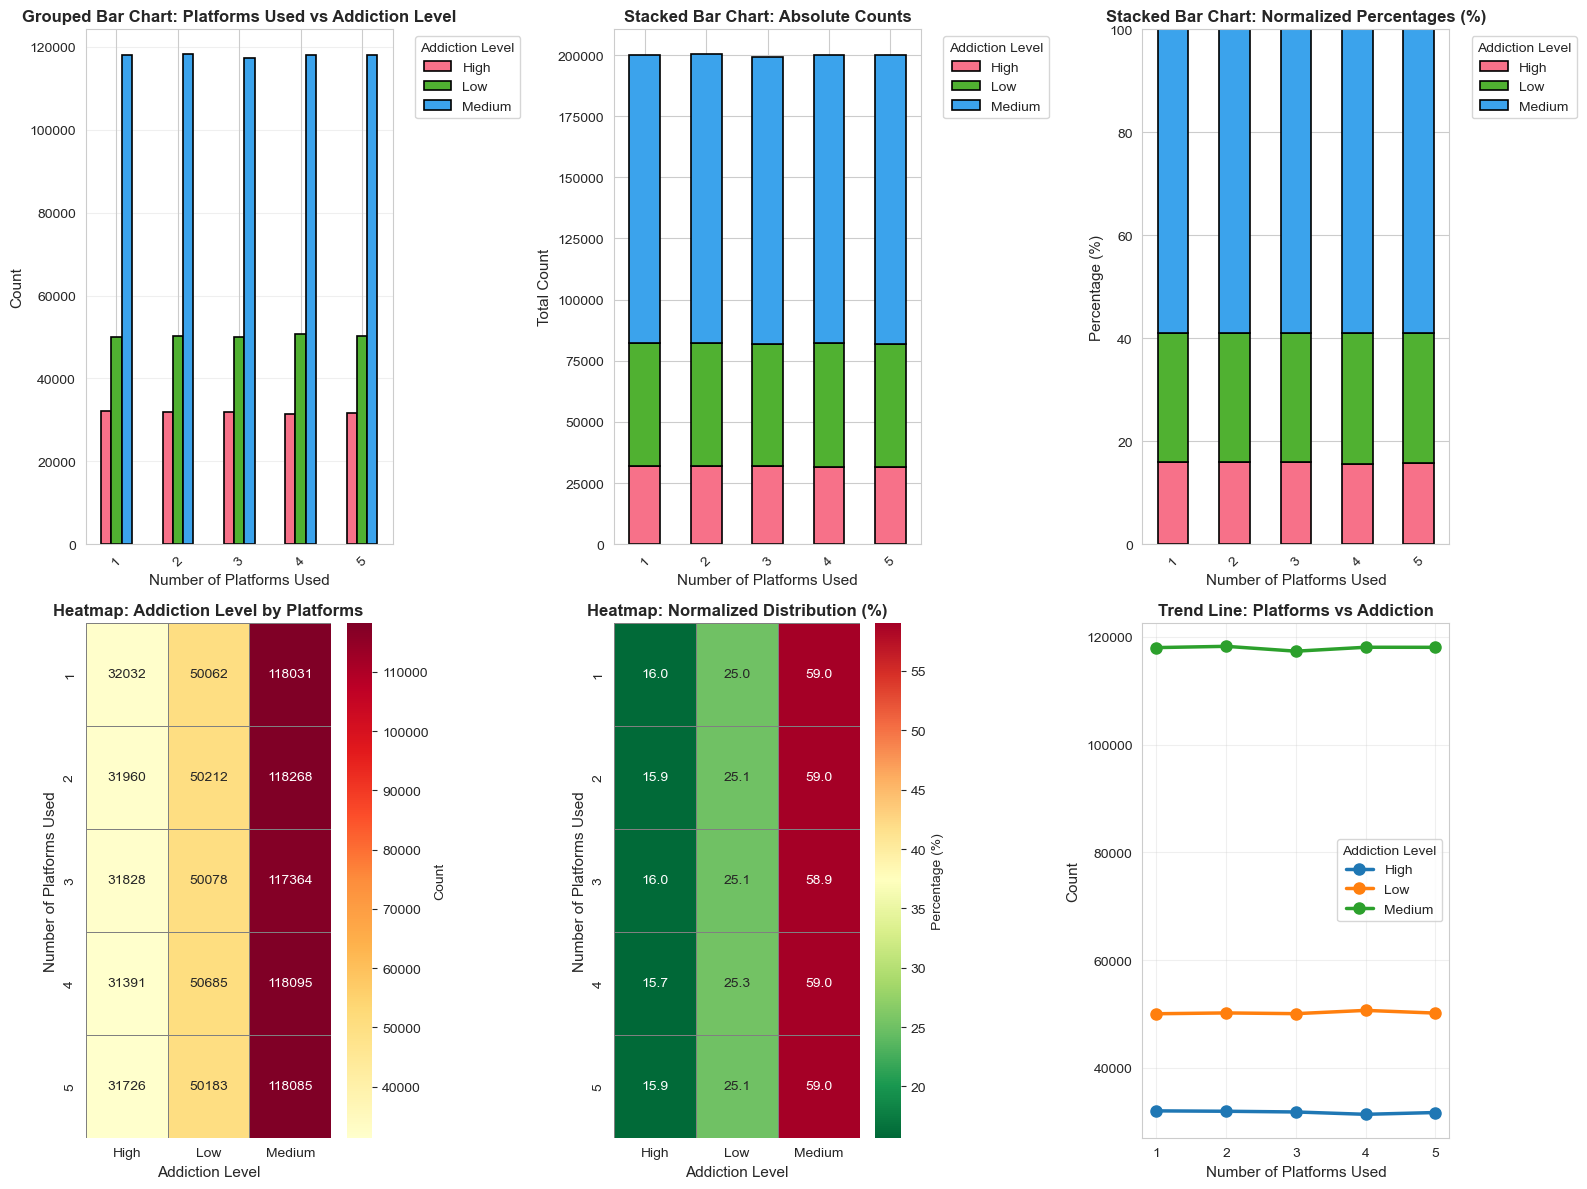

✓ Saved: RQ5_Distribution_Analysis.png


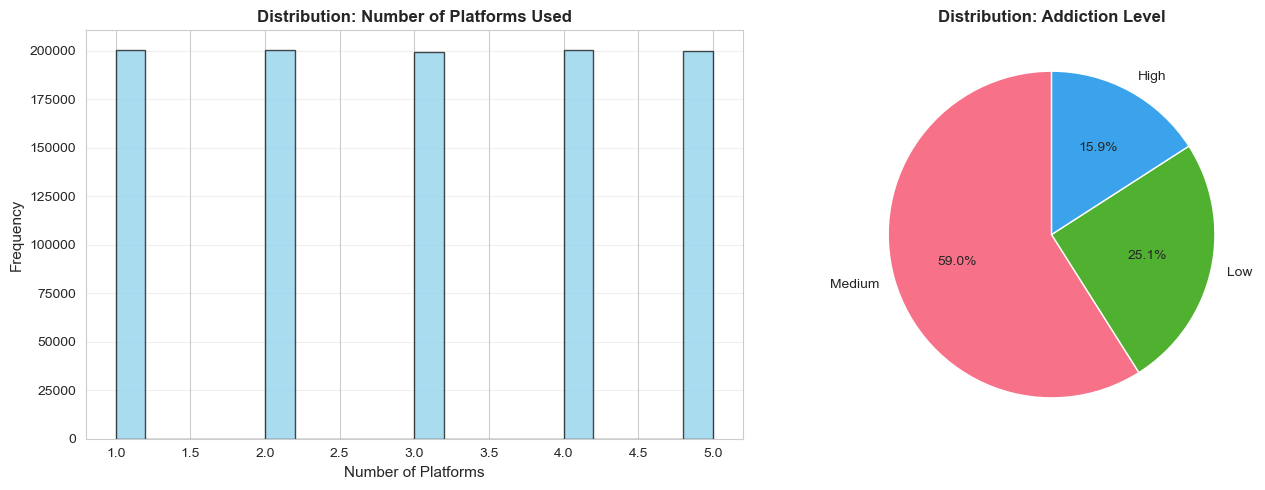


ANALYSIS COMPLETE ✓

Generated Files:
  1. RQ5_Crosstab_Platforms_Addiction.csv
  2. RQ5_Normalized_Percentages.csv
  3. RQ5_Summary_Statistics.csv
  4. RQ5_Comprehensive_Analysis.png
  5. RQ5_Distribution_Analysis.png



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# Configure paths
BASE_DIR = os.path.dirname(os.path.abspath(''))
DATA_PATH = os.path.join(BASE_DIR, "data", "genz_social_media_usage_1M.csv")
OUTPUT_DIR = os.path.join(BASE_DIR, "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Configure visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 10

# ============================================================================
# 1. LOAD AND VALIDATE DATA
# ============================================================================
try:
    print("📊 Loading data...")
    df = pd.read_csv('genz_social_media_usage_1Million.csv')
    print(f"✓ Dataset loaded successfully: {df.shape[0]} rows, {df.shape[1]} columns\n")
except FileNotFoundError:
    print(f"❌ Error: File not found at {DATA_PATH}")
    raise
except Exception as e:
    print(f"❌ Error loading data: {str(e)}")
    raise

# ============================================================================
# 2. DATA EXPLORATION
# ============================================================================
print("="*70)
print("DATA OVERVIEW")
print("="*70)
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}\n")

# Check for missing values
print(f"Missing Values:\n{df.isnull().sum()}\n")

# ============================================================================
# 3. CREATE CROSSTAB ANALYSIS
# ============================================================================
print("="*70)
print("CROSSTAB: NUMBER OF PLATFORMS vs ADDICTION LEVEL")
print("="*70)

# Basic crosstab
crosstab_table = pd.crosstab(
    df["num_platforms_used"], 
    df["addiction_level"],
    margins=True
)
print("\n1. Frequency Distribution:")
print(crosstab_table)

# Save raw crosstab
crosstab_table.to_csv(f"{OUTPUT_DIR}/RQ5_Crosstab_Platforms_Addiction.csv")
print(f"\n✓ Crosstab saved to: RQ5_Crosstab_Platforms_Addiction.csv")

# ============================================================================
# 4. NORMALIZED PERCENTAGES
# ============================================================================
print("\n" + "="*70)
print("NORMALIZED PERCENTAGES (Row-wise)")
print("="*70)

crosstab_normalized = pd.crosstab(
    df["num_platforms_used"], 
    df["addiction_level"],
    normalize='index'
) * 100

crosstab_normalized_rounded = crosstab_normalized.round(2)
print("\n" + crosstab_normalized_rounded.to_string())

# Save normalized percentages
crosstab_normalized_rounded.to_csv(f"{OUTPUT_DIR}/RQ5_Normalized_Percentages.csv")
print(f"\n✓ Normalized percentages saved")

# ============================================================================
# 5. SUMMARY STATISTICS
# ============================================================================
print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)

summary_stats = pd.DataFrame({
    'Metric': [
        'Total Records',
        'Unique Platforms',
        'Unique Addiction Levels',
        'Mean Platforms Used',
        'Median Platforms Used',
        'Std Dev Platforms',
        'Min Platforms',
        'Max Platforms'
    ],
    'Value': [
        df.shape[0],
        df["num_platforms_used"].nunique(),
        df["addiction_level"].nunique(),
        f"{df["num_platforms_used"].mean():.2f}",
        f"{df["num_platforms_used"].median():.2f}",
        f"{df["num_platforms_used"].std():.2f}",
        df["num_platforms_used"].min(),
        df["num_platforms_used"].max()
    ]
})

print("\n" + summary_stats.to_string(index=False))
summary_stats.to_csv(f"{OUTPUT_DIR}/RQ5_Summary_Statistics.csv", index=False)
print(f"\n✓ Summary statistics saved")

# ============================================================================
# 6. VISUALIZATIONS
# ============================================================================
print("\n" + "="*70)
print("GENERATING VISUALIZATIONS")
print("="*70)

# Create figure with multiple subplots
fig = plt.figure(figsize=(16, 12))

# 1. Grouped Bar Chart
ax1 = plt.subplot(2, 3, 1)
crosstab_table.drop('All', axis=0).drop('All', axis=1).plot(
    kind='bar',
    ax=ax1,
    color=sns.color_palette("husl", len(df["addiction_level"].unique())),
    edgecolor='black',
    linewidth=1.2
)
ax1.set_title('Grouped Bar Chart: Platforms Used vs Addiction Level', fontsize=12, fontweight='bold')
ax1.set_xlabel('Number of Platforms Used', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.legend(title='Addiction Level', bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(axis='y', alpha=0.3)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# 2. Stacked Bar Chart (Absolute)
ax2 = plt.subplot(2, 3, 2)
crosstab_table.drop('All', axis=0).drop('All', axis=1).plot(
    kind='bar',
    stacked=True,
    ax=ax2,
    color=sns.color_palette("husl", len(df["addiction_level"].unique())),
    edgecolor='black',
    linewidth=1.2
)
ax2.set_title('Stacked Bar Chart: Absolute Counts', fontsize=12, fontweight='bold')
ax2.set_xlabel('Number of Platforms Used', fontsize=11)
ax2.set_ylabel('Total Count', fontsize=11)
ax2.legend(title='Addiction Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

# 3. Stacked Bar Chart (Normalized %)
ax3 = plt.subplot(2, 3, 3)
crosstab_normalized.plot(
    kind='bar',
    stacked=True,
    ax=ax3,
    color=sns.color_palette("husl", len(df["addiction_level"].unique())),
    edgecolor='black',
    linewidth=1.2
)
ax3.set_title('Stacked Bar Chart: Normalized Percentages (%)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Number of Platforms Used', fontsize=11)
ax3.set_ylabel('Percentage (%)', fontsize=11)
ax3.legend(title='Addiction Level', bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.set_ylim(0, 100)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45)

# 4. Heatmap
ax4 = plt.subplot(2, 3, 4)
heatmap_data = crosstab_table.drop('All', axis=0).drop('All', axis=1)
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    cbar_kws={'label': 'Count'},
    ax=ax4,
    linewidths=0.5,
    linecolor='gray'
)
ax4.set_title('Heatmap: Addiction Level by Platforms', fontsize=12, fontweight='bold')
ax4.set_xlabel('Addiction Level', fontsize=11)
ax4.set_ylabel('Number of Platforms Used', fontsize=11)

# 5. Normalized Heatmap (%)
ax5 = plt.subplot(2, 3, 5)
sns.heatmap(
    crosstab_normalized,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',
    cbar_kws={'label': 'Percentage (%)'},
    ax=ax5,
    linewidths=0.5,
    linecolor='gray'
)
ax5.set_title('Heatmap: Normalized Distribution (%)', fontsize=12, fontweight='bold')
ax5.set_xlabel('Addiction Level', fontsize=11)
ax5.set_ylabel('Number of Platforms Used', fontsize=11)

# 6. Line Plot (Trends)
ax6 = plt.subplot(2, 3, 6)
for col in crosstab_table.drop('All', axis=1).columns:
    if col != 'All':
        ax6.plot(
            crosstab_table.drop('All', axis=0).index,
            crosstab_table.drop('All', axis=0)[col],
            marker='o',
            linewidth=2.5,
            markersize=8,
            label=col
        )
ax6.set_title('Trend Line: Platforms vs Addiction', fontsize=12, fontweight='bold')
ax6.set_xlabel('Number of Platforms Used', fontsize=11)
ax6.set_ylabel('Count', fontsize=11)
ax6.legend(title='Addiction Level')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/RQ5_Comprehensive_Analysis.png", dpi=300, bbox_inches='tight')
print("✓ Saved: RQ5_Comprehensive_Analysis.png")
plt.show()

# ============================================================================
# 7. ADDITIONAL DETAILED VISUALIZATIONS
# ============================================================================

# Distribution of platforms used
fig2, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df["num_platforms_used"], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution: Number of Platforms Used', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Platforms', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Addiction level distribution
addiction_counts = df["addiction_level"].value_counts()
colors = sns.color_palette("husl", len(addiction_counts))
axes[1].pie(
    addiction_counts.values,
    labels=addiction_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 10}
)
axes[1].set_title('Distribution: Addiction Level', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/RQ5_Distribution_Analysis.png", dpi=300, bbox_inches='tight')
print("✓ Saved: RQ5_Distribution_Analysis.png")
plt.show()

# ============================================================================
# 8. FINAL SUMMARY
# ============================================================================
print("\n" + "="*70)
print("ANALYSIS COMPLETE ✓")
print("="*70)
print("\nGenerated Files:")
print(f"  1. RQ5_Crosstab_Platforms_Addiction.csv")
print(f"  2. RQ5_Normalized_Percentages.csv")
print(f"  3. RQ5_Summary_Statistics.csv")
print(f"  4. RQ5_Comprehensive_Analysis.png")
print(f"  5. RQ5_Distribution_Analysis.png")
print("\n" + "="*70)